# Классификация текстов: Bag of Words и логистическая регрессия

**Датасет:** Reviews (Kaggle, `ahmedabdulhamid/reviews-dataset`) — 4321 запись, текст отзыва `review` и бинарная метка `class` (положительный / отрицательный).

**Шаги:**
1. Загрузка данных, первичный осмотр и примеры отзывов.
2. Векторизация корпуса (CountVectorizer), анализ частот признаков.
3. Разделение на train/test, обучение логистической регрессии.
4. Метрики на тесте, матрица ошибок, подбор порога классификации по F1.
5. Визуализация и разбор типичных ошибок модели.


In [1]:
# Установка зависимостей
!pip install scikit-learn pandas kagglehub seaborn

In [2]:
# Импорт зависимостей
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Загрузка датасета
data_path = kagglehub.dataset_download("ahmedabdulhamid/reviews-dataset")
df = pd.read_csv(f"{data_path}/TestReviews.csv")

In [4]:
# Вывод информации о данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  4321 non-null   str  
 1   class   4321 non-null   int64
dtypes: int64(1), str(1)
memory usage: 67.6 KB


In [5]:
# Обновление столбца class
df['isPositive'] = df['class'].astype(bool)
df = df.drop(columns=['class'])

In [6]:
# Несколько примеров положительных отзывов.
df[df['isPositive']].head()

,review,isPositive
0,Fantastic spot for an even or a quite cocktail...,True
1,"Love, love, love the calamari. It's so good an...",True
2,"Love this place. Stiff martinis and cocktails,...",True
3,It's everything a great cocktail bar should be...,True
4,"I came here before a pirates game, so it was a...",True


In [7]:
# Несколько примеров отрицательных отзывов.
df[~df['isPositive']].head()

,review,isPositive
2989,Has to be one of the worst place for a trade s...,False
2990,I have been a AAA member for over 15 years. To...,False
2991,"I dont know how to begin my utter disgust, dis...",False
2992,I had a horrible experience with towing. I cal...,False
2993,You would think their exorbitant prices would ...,False


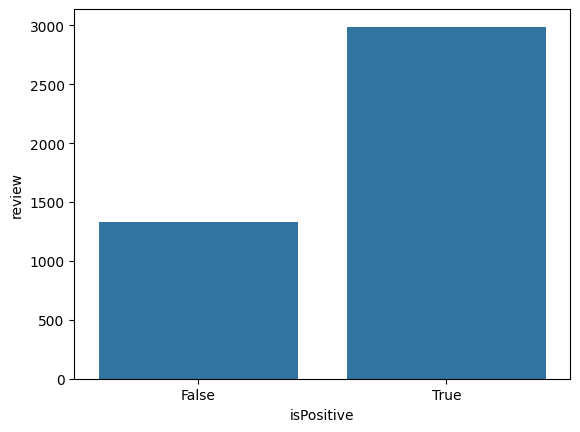

In [8]:
# Распределение данных по типу отзыва
sns.barplot(df.groupby('isPositive')['review'].count())
plt.show()

In [9]:
# Тексты отзывов и целевую метку в отдельные переменные.
reviews = df['review']
targets = df['isPositive']

In [10]:
# Обучение CountVectorizer на корпусе.
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.99,
    stop_words='english',
)

reviews_vectorized = bow.fit_transform(reviews)

In [11]:
# Преобразование в DataFrame для EDA
reviews_vectorized_df = pd.DataFrame(
    reviews_vectorized.toarray(),
    columns=bow.get_feature_names_out()
)

In [12]:
# Сортировка признаков по суммарной частоте встречаемости по всему корпусу.
reviews_vectorized_df.sum().sort_values(ascending=False)

place           2726
great           1900
like            1878
time            1740
just            1696
                ... 
closes             8
closing time       8
club great         8
signing            8
trek               8
Length: 5000, dtype: int64

In [13]:
# Проверка числа строк и столбцов в таблице признаков.
reviews_vectorized_df.shape

(4321, 5000)

Обучим простую модель на подготовленных выше данных

---

In [14]:
# Подготовка данных для тренировки и тестирования
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(reviews, targets, test_size=0.2, random_state=42)

In [15]:
# Создание BoW только на тестовой выборке
bow = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.99,
    stop_words='english',
)

bow.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 151469 stored elements and shape (3456, 5000)>

In [16]:
# Обучение модели
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(bow.transform(X_train), y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
# Получение тестовых результатов
predictions = model.predict(bow.transform(X_test))

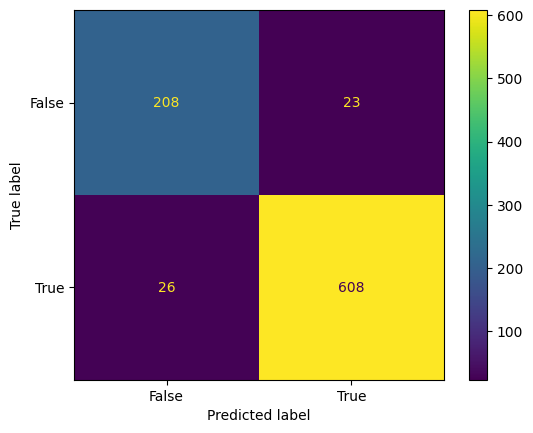

In [18]:
# Матрица ошибок
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()

In [19]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Precision: среди всех предсказанных положительных - сколько реально положительные
print(f"Precision: {precision_score(y_test, predictions)}")

# Recall: среди всех реальных положительных - сколько модель нашла
print(f"Recall: {recall_score(y_test, predictions)}")

# F1 Score: баланс между precision и recall (гармоническое среднее)
print(f"F1 Score: {f1_score(y_test, predictions)}")

Precision: 0.9635499207606973
Recall: 0.9589905362776026
F1 Score: 0.9612648221343874


Улучшим модель с помощью перебора порога и поиска лучшего F1 Score

---

In [20]:
# Коэффициенты уверенности модели в том, что отзыв положительный
prediction_coefs = model.predict_proba(bow.transform(X_test))[:, 1]

In [21]:
# Расчет precision и recall в зависимости от порога (threshold)
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, prediction_coefs)

In [22]:
# Расчет f1 метрики, для выбора самой оптимальной модели
f1 = 2 * (precision * recall) / (precision + recall)

In [23]:
# Получение индекса максимального f1 в рассчетах
f1_max_index = f1.argmax()

In [24]:
best_threshold = thresholds[f1_max_index]

In [25]:
# Вывод полученных лучших метрик
print(f"Max F1 score: {f1[f1_max_index]}")
print(f"Max precision: {precision[f1_max_index]}")
print(f"Max recall: {recall[f1_max_index]}")
print(f"Best threshold: {best_threshold}")

Max F1 score: 0.9620253164556963
Max precision: 0.9650793650793651
Max recall: 0.9589905362776026
Best threshold: 0.5127988904342871


In [26]:
# Получение предсказаний с учетом полученного лучшего порога
predictions = model.predict_proba(bow.transform(X_test))[:,1] >= best_threshold

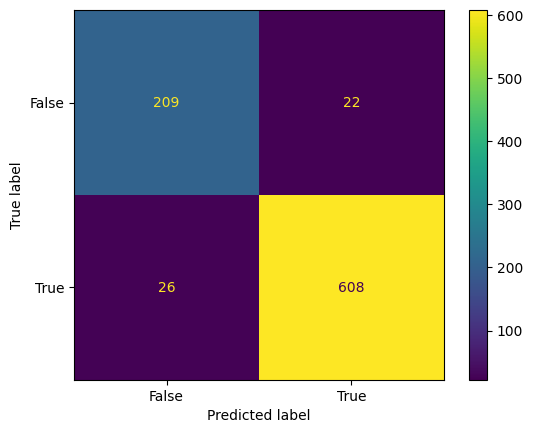

In [27]:
# Визуализация
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()

Так как модель сразу себя хорошо показала, то изменение порога малозначительно улучшило качество модели. На тестовой выборке стало на 1 ложноположительное предсказание меньше

Сделаем еще две модели с максимальным precision и recall

In [ ]:
# При precision=1
precision_max_index = precision.argmax()

predictions = model.predict_proba(bow.transform(X_test))[:,1] >= thresholds[precision_max_index]

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()

print(f"Threshold: {thresholds[precision_max_index]}")
print(f"Max F1 score: {f1[precision_max_index]}")

Теперь модель не засчитывает отрицательные отзывы за положительные, но при этом половина отзывов ложно считается отрицательными.

Может подойти для случаев, когда требуется найти только положительные отзывы

In [ ]:
# При recall=1
recall_max_index = recall.argmax()

predictions = model.predict_proba(bow.transform(X_test))[:,1] >= thresholds[recall_max_index]

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()

print(f"Threshold: {thresholds[recall_max_index]}")
print(f"F1 score: {f1[recall_max_index]}")

Модель стала дегенеративной. При recall = 1 и засчитала все комментарии за положительные.

Может подойти для случаев, когда нужно рассмотреть все варианты. Вот только строить модель в таком случае не требуется

После разбора крайностей, оценим графики изменения метрик для полноты картины:

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(model, bow.transform(X_test), y_test)
plt.show()

Модель показывает почти идеальное разделение классов: precision остаётся очень высоким при росте recall (AP ≈ 0.99).

Рассмотрим отзывы из тестовой выборки, характер которых не смогла правильно предсказать лучшая построенная модель

In [ ]:
# Соберем обратно отзывы и их характер в один DataFrame
df_test = pd.DataFrame(X_test).join(y_test)

In [32]:
# Снова посчитаем предсказания модели по самому оптимальному порогу
df_test['prediction'] = model.predict_proba(bow.transform(X_test))[:,1] >= best_threshold

In [33]:
# Ложно отрицательные отзывы
df_test[df_test['isPositive'] & (~df_test['prediction'])]

In [34]:
# Ложно положительные отзывы
df_test[(~df_test['isPositive']) & df_test['prediction']]

,review,isPositive,prediction
1721,"While in Madison for a day, I needed to find t...",True,False
803,Trust Tim & Brenda to handle all your embroide...,True,False
2942,Burgundy Pepper Steak. Get one of these and yo...,True,False
1149,I went to Karla for eyeliner and I couldn't ha...,True,False
551,"This is semi new, they've been open for at lea...",True,False
1729,"I've been going to this Zia for 15 years. Yes,...",True,False
731,Waiting to review...been coming here for a whi...,True,False
2598,In a last ditch attempt at exhibiting what may...,True,False
371,I'm not sure how it took my wife & I so long t...,True,False
2676,"""If you want a good, tasty, budget brat,"" says...",True,False


Характер этих отзывов явно предсказан моделью некорректно. Работы по улучшению качества предсказаний продолжим в другом ноутбуке с применением TF-IDF вместо BoW

Характер этих отзывов явно предсказан моделью некорректно. Работы по улучшению качества предсказаний продолжим в другом ноутбуке с применением TF-IDF вместо BoW